In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
from time import sleep
from dotenv import load_dotenv

load_dotenv()

False

In [26]:
class TempState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [27]:
def node1(state: TempState) -> dict:
    print("Node 1 Executing...")
    return {"input": state["input"], "step1": "done"}

In [38]:
def node2(state: TempState) -> dict:
    print("Node 2 Executing...")
    print("Time stopped")
    sleep(30)
    return {"step2": "done"}

In [39]:
def node3(state: TempState) -> dict:
    print("Node 3 Executing...")
    return {"step3": "done"}

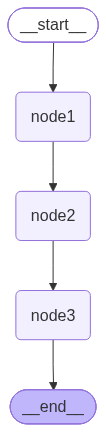

In [40]:
graph = StateGraph(TempState)

graph.add_node("node1", node1)
graph.add_node("node2", node2)
graph.add_node("node3", node3)

graph.add_edge(START, "node1")
graph.add_edge("node1", "node2")
graph.add_edge("node2", "node3")
graph.add_edge("node3", END)

workflow = graph.compile(checkpointer=InMemorySaver())
workflow

In [41]:
try:
    input_state = {
        "input": "start"
    }

    config = {
        "configurable" : {
            "thread_id" : 1
        }
    }

    workflow.invoke(input_state, config=config)

except KeyboardInterrupt:
    print("Execution interrupted")


Node 1 Executing...
Node 2 Executing...
Time stopped
Execution interrupted


In [44]:
print(workflow.get_state(config=config))

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51da-6cae-8001-c1d417fe7e34'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-25T08:25:51.431567+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51d5-6b59-8000-0f4b1e8eacb9'}}, tasks=(PregelTask(id='f32c3b0a-cb17-0542-cd71-cf8e2de1f22c', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(), state=None, result=None),), interrupts=())


In [46]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51da-6cae-8001-c1d417fe7e34'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-25T08:25:51.431567+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51d5-6b59-8000-0f4b1e8eacb9'}}, tasks=(PregelTask(id='f32c3b0a-cb17-0542-cd71-cf8e2de1f22c', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('node1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51d5-6b59-8000-0f4b1e8eacb9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-25T08:25:51.429476+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51d2-6d5

In [47]:
# Restart leads to restarting from left stage and not from start
workflow.invoke(None, config=config)

Node 2 Executing...
Time stopped
Node 3 Executing...


{'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}

In [48]:
workflow.get_state(config=config)

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05ed-d0ef-667a-8003-85fa1b5dae59'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-25T08:27:52.131089+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05ed-d0d8-6741-8002-63efbaa959a6'}}, tasks=(), interrupts=())

In [50]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05ed-d0ef-667a-8003-85fa1b5dae59'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-25T08:27:52.131089+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05ed-d0d8-6741-8002-63efbaa959a6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('node3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05ed-d0d8-6741-8002-63efbaa959a6'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-25T08:27:52.121693+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05e9-51da-6cae-8001-c1d417fe7e34'}}, tasks=(PregelTask(id='50d66e4f-ec2b-6891-7c37-903b620ac7ec', name='no